In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
df.describe()


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [6]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

## 2.1 Load & Inspect — Summary

- The dataset contains 187,531 rows and 21 columns.
- Most columns are stored as text (`str`), even ones that are logically numeric, such as `Bathroom`, `Balcony`, and `Floor`.
- Only 4 columns are truly numeric: `Index`, `Price (in rupees)`, `Dimensions`, and `Plot Area`.
- `Dimensions` and `Plot Area` are 100% missing and will be dropped.
- `Society` (58.5%), `Super Area` (57.4%), and `Car Parking` (55.1%) have the most missing values among usable columns.
- The actual price column to use is `Amount(in rupees)` (0% missing, but stored as messy text like "42 Lac" or "1.2 Cr") — not `Price (in rupees)`, which is 9.4% missing and appears to be a separate, less reliable field.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

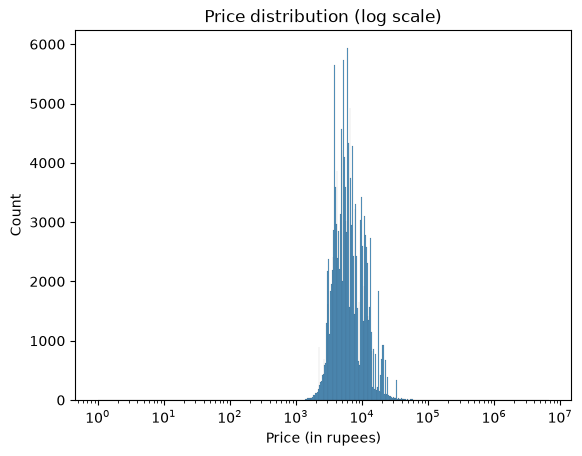

In [8]:
sns.histplot(df["Price (in rupees)"].dropna(), log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

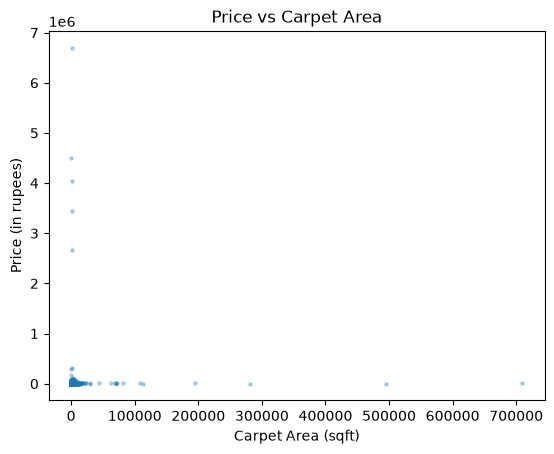

In [9]:
carpet_numeric = df["Carpet Area"].str.extract(r"(\d+)").astype(float)
plt.scatter(carpet_numeric, df["Price (in rupees)"], alpha=0.3, s=5)
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (in rupees)")
plt.title("Price vs Carpet Area")
plt.show()

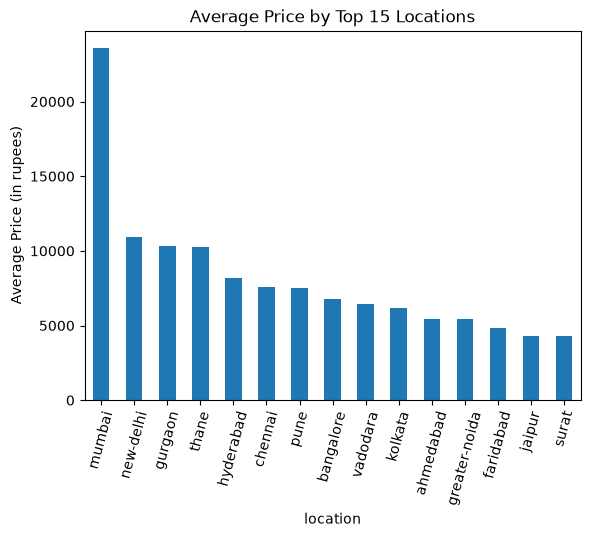

In [10]:
top_locations = df["location"].value_counts().head(15).index
avg_price = df[df["location"].isin(top_locations)].groupby("location")["Price (in rupees)"].mean().sort_values(ascending=False)
avg_price.plot(kind="bar")
plt.ylabel("Average Price (in rupees)")
plt.title("Average Price by Top 15 Locations")
plt.xticks(rotation=75)
plt.show()

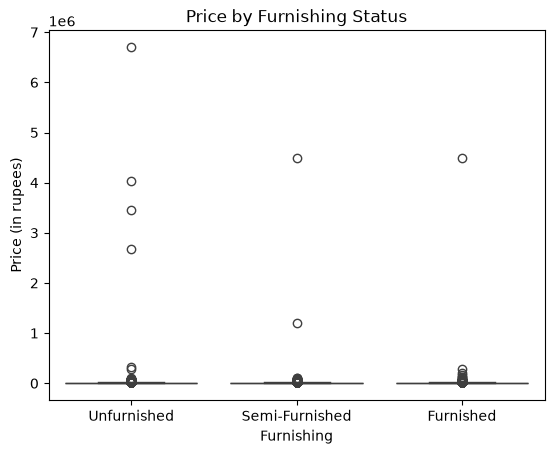

In [11]:
sns.boxplot(data=df, x="Furnishing", y="Price (in rupees)")
plt.title("Price by Furnishing Status")
plt.show()

## 2.2 EDA — Observations

- **Price distribution (log scale):** Roughly bell-shaped once log-scaled, with small gaps in the middle — likely reflecting clustering around common round price points.
- **Price vs Carpet Area:** A cluster of points appears at carpet area = 0, which is not realistic — this points to parsing issues in the `Carpet Area` column (e.g. text values that didn't match our number-extraction pattern) that need to be handled properly during cleaning.
- **Average price by top 15 locations:** Mumbai stands out as by far the most expensive location, consistent with real-world expectations for the Indian property market.
- **Price by furnishing status:** Unfurnished listings show higher median prices than Furnished ones, which is counter-intuitive — this may reflect inconsistent or messy values in the `Furnishing` column rather than a genuine market pattern, and should be treated cautiously.

In [12]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

In [13]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().strip()
    try:
        num = float(''.join(c for c in x if c.isdigit() or c == '.'))
        if "sqm" in x:
            return num * 10.764
        return num
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

In [14]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.lower().strip()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    try:
        return float(x.split("out")[0].strip())
    except (ValueError, IndexError):
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [15]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce").fillna(df["Bathroom"].mode()[0])
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce").fillna(0)
df["car_parking"] = pd.to_numeric(df["Car Parking"], errors="coerce").fillna(0)

In [16]:
top_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].apply(lambda x: x if x in top_locations else "other")

In [17]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area",
                       "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area",
                       "Floor", "Bathroom", "Balcony", "Car Parking", "location", "Society"])
df.shape

(177847, 14)

In [18]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= lower) & (df["price_per_sqft"] <= upper) | (df["price_per_sqft"].isna())]
df.shape

(176293, 15)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [20]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

x = df[numeric_features + categorical_features]
y = df["price_clean"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
model_lr = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
model_lr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [22]:
model_rf = Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
model_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [23]:
import os
print(os.cpu_count())

8


In [24]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

for name, model in [("Linear Regression", model_lr), ("Random Forest", model_rf)]:
    pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")

Linear Regression: MAE=4687514.53, RMSE=8890564.45, R2=0.5776
Random Forest: MAE=1354452.18, RMSE=5705804.46, R2=0.8260


## 2.5 Model Comparison

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 4,687,514.53 | 8,890,564.45 | 0.5776 |
| Random Forest | 1,354,452.18 | 5,705,804.46 | 0.8260 |

**Winner: Random Forest.** It explains 82.6% of the variance in house price on the test set, compared to only 57.8% for Linear Regression, and its average prediction error (MAE) is roughly 3.5x lower. This makes sense given the nature of the data — the relationship between features like location, area, and furnishing status and the final price is unlikely to be purely linear (e.g. Mumbai properties don't just add a fixed amount to price — the effect of location likely interacts with other features). Random Forest captures these non-linear relationships and feature interactions, which Linear Regression cannot.

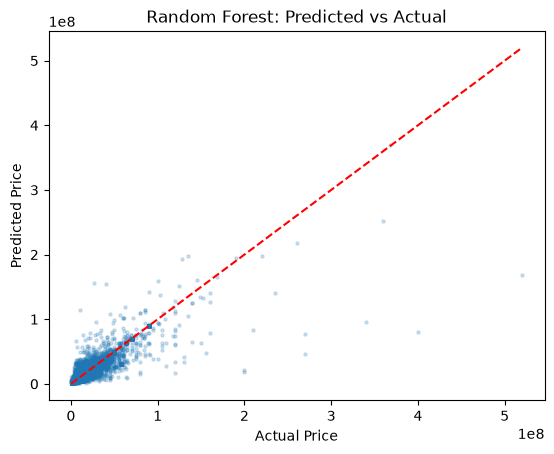

In [25]:
import matplotlib.pyplot as plt

pred_rf = model_rf.predict(x_test)

plt.scatter(y_test, pred_rf, alpha=0.2, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

In [26]:
import joblib

joblib.dump(model_rf, "house_price.pkl")

['house_price.pkl']

In [27]:
loaded = joblib.load("house_price.pkl")
sample = x_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [7708702.18253968]


In [28]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

In [29]:
import sklearn
print(sklearn.__version__)

1.9.0
